# 10. XEB workflow

使用很小的参数运行 1q XEB，覆盖校准、ReadoutEM、随机线路生成、fidelity 拟合和结果图示。
本 notebook 使用 `backend="dummy"` 搭配显式 `noise_model` 做本地含噪发布检查；如果要检查真实芯片标定噪声路径，应改用 `backend="dummy:originq:WK_C180"` 这类规则型 backend id，它会先按真实 backend compile/transpile，再本地含噪执行。
发布前可以提高 `n_circuits` 和 `shots` 做更严格的人工检查。


fidelity_per_layer: 0.983341
fit parameters: {'A': 1.01276, 'B': 0.0, 'r': 0.983341}
depths: (1, 2, 3)


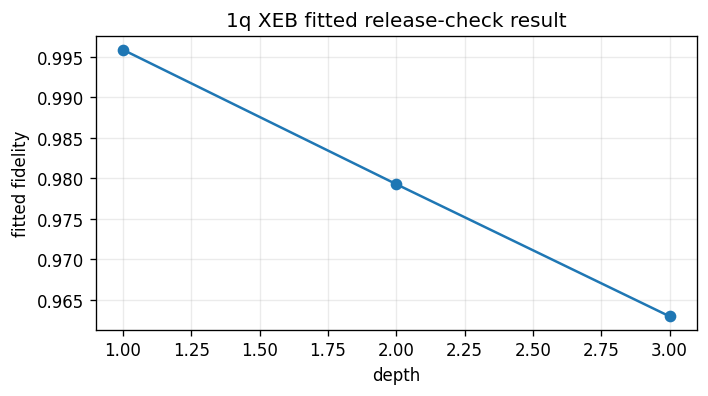

In [1]:
import tempfile
import matplotlib.pyplot as plt

from uniqc import xeb_workflow

cache_dir = tempfile.mkdtemp(prefix="uniqc-bp-xeb-")
results = xeb_workflow.run_1q_xeb_workflow(
    backend="dummy",
    qubits=[0],
    depths=[1, 2, 3],
    n_circuits=3,
    shots=128,
    use_readout_em=True,
    noise_model={"depol": 0.01, "readout": 0.04},
    seed=11,
    cache_dir=cache_dir,
)

result = results[0]
print("fidelity_per_layer:", round(result.fidelity_per_layer, 6))
print("fit parameters:", {"A": round(result.fit_a, 6), "B": round(result.fit_b, 6), "r": round(result.fit_r, 6)})
print("depths:", result.depths)

fitted = [result.fit_a * (result.fit_r ** depth) + result.fit_b for depth in result.depths]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(result.depths, fitted, marker="o")
ax.set_xlabel("depth")
ax.set_ylabel("fitted fidelity")
ax.set_title("1q XEB fitted release-check result")
ax.grid(alpha=0.25)
fig.tight_layout()
